In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Mounted at /content/drive


In [2]:
# Loading the training and testing pre-processed dataset
train_dat = pd.read_csv('/content/drive/MyDrive/COMM074_Project/preprocessed/train_preprocessed.csv')
test_dat = pd.read_csv('/content/drive/MyDrive/COMM074_Project/preprocessed/test_preprocessed.csv')

In [3]:
# Checking the training data's summary
train_dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 69 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   admission_grade                                                                  3539 non-null   float64
 1   previous_qualification_grade                                                     3539 non-null   float64
 2   age_at_enrollment                                                                3539 non-null   float64
 3   tuition_fees_up_to_date_Yes                                                      3539 non-null   float64
 4   unemployment_rate                                                                3539 non-null   float64
 5   gdp                                                                              3539 non-null   float64
 6   scholars

Creating and Training the Baseline LDA model on our dataset


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

# Importing necessary metrics for evaluation of predictions
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score, f1_score

Y_train = train_dat.target
X_train = train_dat.drop('target',axis=1)

Y_test = test_dat.target
X_test = test_dat.drop('target',axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lda = LDA()

# Training the LDA model
lda.fit(X_train_scaled,Y_train)
ldaY_pred = lda.predict(X_test_scaled)

weighted_F1_lda = f1_score(Y_test,ldaY_pred,average='weighted')
macro_F1_lda = f1_score(Y_test,ldaY_pred,average='macro')
bal_acc_lda = balanced_accuracy_score(Y_test,ldaY_pred)
class_report_lda = classification_report(Y_test,ldaY_pred)
conf_matrix_lda = confusion_matrix(Y_test,ldaY_pred)

print(f" Weighted F1 Score - {weighted_F1_lda}")
print(f"\n Macro F1 Score - {macro_F1_lda}")
print(f"\n Balanced accuracy score: {bal_acc_lda}")
print(f"\n Classification report: \n{class_report_lda}")
print(f"\n Confusion matrix - \n{conf_matrix_lda}")

 Weighted F1 Score - 0.6150739485247959

 Macro F1 Score - 0.5386172839506173

 Balanced accuracy score: 0.5334121083444997

 Classification report: 
              precision    recall  f1-score   support

           0       0.72      0.55      0.62       284
           1       0.31      0.21      0.25       159
           2       0.66      0.84      0.74       442

    accuracy                           0.63       885
   macro avg       0.56      0.53      0.54       885
weighted avg       0.62      0.63      0.62       885


 Confusion matrix - 
[[156  35  93]
 [ 30  34  95]
 [ 30  42 370]]


Heatmap of LDA's Confusion Matrix (Before Hyperparameter-tuning)

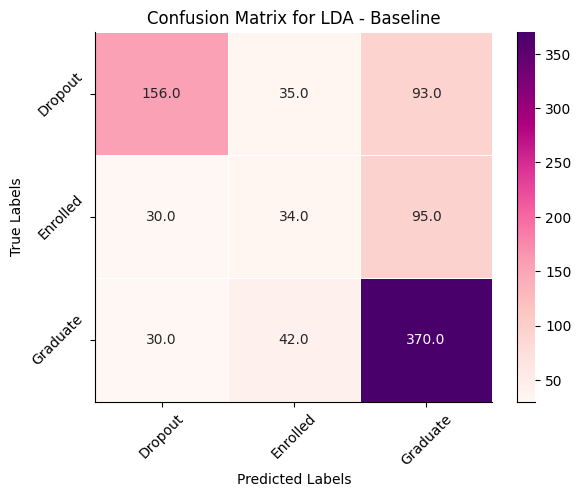

In [5]:
classnames = ['Dropout','Enrolled','Graduate']
cm_LDA = confusion_matrix(Y_test,ldaY_pred,labels=[0,1,2])
lda_heatmap = sns.heatmap(cm_LDA,annot=True,fmt=".1f",linewidth=0.5,cmap='RdPu',
            xticklabels = classnames, yticklabels = classnames)

lda_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
lda_heatmap.set_title('Confusion Matrix for LDA - Baseline')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

Cross-Validation on LDA classifier using GridSearchCV

In [6]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

kfold = StratifiedKFold(n_splits=5, shuffle=True)

# Change param_grid to using LDA's parameter ranges
param_grid_lda = [
    {'solver':['svd']},
    {'solver':['lsqr','eigen'],
    'shrinkage': [0.1,0.3,0.4,0.45,0.62,0.85,0.95]}
]

lda_grid = GridSearchCV(lda, param_grid_lda, scoring='f1_macro', cv=kfold)
lda_best = lda_grid.fit(X_train_scaled,Y_train)

# Primary scoring metric used is Macro_F1
print(f'Best Macro_F1 Score: {lda_best.best_score_} for {lda_best.best_params_}')

best_estimator_lda = lda_best.best_estimator_

# Computing best predicted values for LDA model using the best estimator
best_ypred_lda = best_estimator_lda.predict(X_test_scaled)

best_weighted_F1_lda = f1_score(Y_test,best_ypred_lda,average='weighted')
best_bal_acc_lda = balanced_accuracy_score(Y_test,best_ypred_lda)
best_class_report_lda = classification_report(Y_test,best_ypred_lda)
best_conf_matrix_lda = confusion_matrix(Y_test,best_ypred_lda)

print(f'\nBest Weighted_F1 Score: {best_weighted_F1_lda:.4f} for {lda_best.best_params_}')
print(f'\nBest Balanced Accuracy Score: {best_bal_acc_lda:.4f} for {lda_best.best_params_}')
print(f'\nClassification Report: \n{best_class_report_lda}')
print(f'\nConfusion Matrix: \n{best_conf_matrix_lda}')

Best Macro_F1 Score: 0.5575618997489936 for {'solver': 'svd'}

Best Weighted_F1 Score: 0.6151 for {'solver': 'svd'}

Best Balanced Accuracy Score: 0.5334 for {'solver': 'svd'}

Classification Report: 
              precision    recall  f1-score   support

           0       0.72      0.55      0.62       284
           1       0.31      0.21      0.25       159
           2       0.66      0.84      0.74       442

    accuracy                           0.63       885
   macro avg       0.56      0.53      0.54       885
weighted avg       0.62      0.63      0.62       885


Confusion Matrix: 
[[156  35  93]
 [ 30  34  95]
 [ 30  42 370]]


LDA's Confusion Matrix (After Hyperparameter-Tuning)

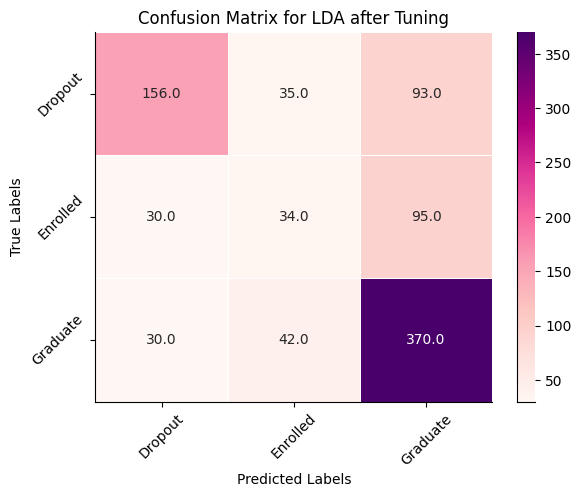

In [7]:
classnames = ['Dropout','Enrolled','Graduate']
cm_LDA = confusion_matrix(Y_test,best_ypred_lda,labels=[0,1,2])
lda_heatmap = sns.heatmap(cm_LDA,annot=True,fmt=".1f",linewidth=0.5,cmap='RdPu',
            xticklabels = classnames, yticklabels = classnames)

lda_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
lda_heatmap.set_title('Confusion Matrix for LDA after Tuning')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

My LDA Model's Baseline vs Tuned Performance Comparison

In [8]:
lda_comparison = pd.DataFrame({
    'Metric': ['Accuracy','Balanced Accuracy','Macro F1', 'Weighted F1'],
    'Baseline': [
        accuracy_score(Y_test,ldaY_pred),
        bal_acc_lda,
        macro_F1_lda,
        weighted_F1_lda
    ],
    'Tuned_model': [
        accuracy_score(Y_test,best_ypred_lda),
        best_bal_acc_lda,
        lda_best.best_score_,
        best_weighted_F1_lda
    ]
})

lda_comparison['Change'] = lda_comparison['Tuned_model'] - lda_comparison['Baseline']
print(lda_comparison.set_index('Metric').round(4).to_string())

                   Baseline  Tuned_model  Change
Metric                                          
Accuracy             0.6328       0.6328  0.0000
Balanced Accuracy    0.5334       0.5334  0.0000
Macro F1             0.5386       0.5576  0.0189
Weighted F1          0.6151       0.6151  0.0000


Creating and Training the Baseline Logistic Regression model on our dataset

In [9]:
from sklearn.linear_model import LogisticRegression

# Using class_weight as 'balanced' since our dataset favors class 2 heavily in predictions
logreg_model = LogisticRegression(
    penalty='elasticnet',
    l1_ratio=0.4,
    class_weight = 'balanced',
    solver='saga',
    max_iter=2000,
    random_state=42
)

logreg_model.fit(X_train_scaled,Y_train)
logY_pred = logreg_model.predict(X_test_scaled)

weighted_F1_log = f1_score(Y_test,logY_pred,average='weighted')
macro_F1_log = f1_score(Y_test,logY_pred,average='macro')
bal_acc_log = balanced_accuracy_score(Y_test,logY_pred)
class_report_log = classification_report(Y_test,logY_pred)
conf_matrix_log = confusion_matrix(Y_test,logY_pred)

print(f" Weighted F1 Score - {weighted_F1_log}")
print(f"\n Macro F1 Score - {macro_F1_log}")
print(f"\n Balanced accuracy score: {bal_acc_log}")
print(f"\n Classification report: \n{class_report_log}")
print(f"\n Confusion matrix - \n{conf_matrix_log}")

 Weighted F1 Score - 0.5950090574314381

 Macro F1 Score - 0.5512561066119303

 Balanced accuracy score: 0.5634910423486498

 Classification report: 
              precision    recall  f1-score   support

           0       0.68      0.58      0.63       284
           1       0.29      0.52      0.37       159
           2       0.73      0.60      0.66       442

    accuracy                           0.58       885
   macro avg       0.57      0.56      0.55       885
weighted avg       0.63      0.58      0.60       885


 Confusion matrix - 
[[164  69  51]
 [ 28  82  49]
 [ 48 130 264]]


Logistic Regression's Confusion Matrix (Before Hyperparameter-tuning)

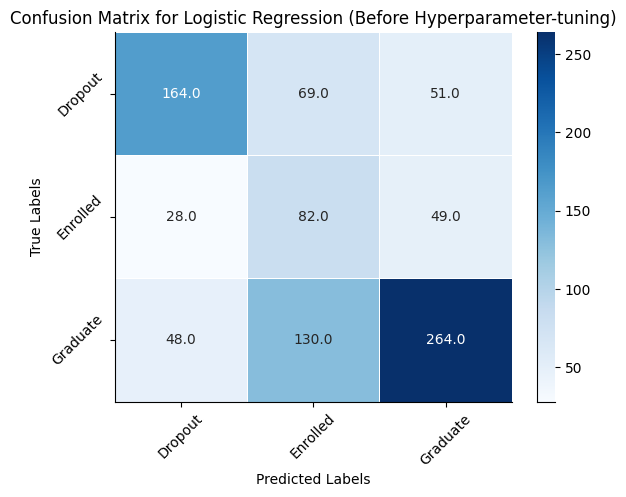

In [10]:
classnames = ['Dropout','Enrolled','Graduate']
cm_logreg = confusion_matrix(Y_test,logY_pred,labels=[0,1,2])

log_heatmap = sns.heatmap(cm_logreg,annot=True,fmt=".1f",linewidth=0.5,cmap='Blues',
            xticklabels = classnames, yticklabels = classnames)

log_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
log_heatmap.set_title('Confusion Matrix for Logistic Regression (Before Hyperparameter-tuning)')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

Cross-Validation on Logistic Regression Classifier using GridSearchCV

In [11]:
# Code snippets taken from Lab4_P2 Classification and modified according to current task
from sklearn.model_selection import GridSearchCV, StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True)

param_grid_log = {'solver': ['saga'],
              'C': [0.001, 0.005, 0.01, 0.35, 0.5, 1, 1.5],
              'penalty': ['elasticnet'],
              'l1_ratio': [0.05, 0.1, 0.3, 0.42, 0.5, 0.7, 0.9],
              'max_iter': [2000,2500]
              }

log_grid = GridSearchCV(logreg_model, param_grid_log, scoring='f1_macro', cv=kfold)
log_best = log_grid.fit(X_train_scaled,Y_train)

# best_estimator_ found from GridSearchCV on sklearn's official documentation - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
best_estimator_logreg = log_best.best_estimator_

# Computing best predicted values for logistic regression model using the best estimator
best_ypred_log = best_estimator_logreg.predict(X_test_scaled)

best_weighted_F1_log = f1_score(Y_test,best_ypred_log,average='weighted')
best_bal_acc_log = balanced_accuracy_score(Y_test,best_ypred_log)
best_class_report_log = classification_report(Y_test,best_ypred_log)
best_conf_matrix_log = confusion_matrix(Y_test,best_ypred_log)

# Primary scoring metric used is Macro_F1
print(f'Best Macro_F1 Score: {log_best.best_score_} for {log_best.best_params_}')

print(f'\nBest Weighted_F1 Score: {best_weighted_F1_log:.4f} for {log_best.best_params_}')
print(f'\nBest Balanced Accuracy Score: {best_bal_acc_log:.4f} for {log_best.best_params_}')
print(f'\nClassification Report: \n{best_class_report_log}')
print(f'\nConfusion Matrix: \n{best_conf_matrix_log}')

Best Macro_F1 Score: 0.57291507263899 for {'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 2000, 'penalty': 'elasticnet', 'solver': 'saga'}

Best Weighted_F1 Score: 0.5922 for {'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 2000, 'penalty': 'elasticnet', 'solver': 'saga'}

Best Balanced Accuracy Score: 0.5622 for {'C': 0.01, 'l1_ratio': 0.05, 'max_iter': 2000, 'penalty': 'elasticnet', 'solver': 'saga'}

Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.57      0.62       284
           1       0.29      0.52      0.37       159
           2       0.73      0.59      0.65       442

    accuracy                           0.57       885
   macro avg       0.57      0.56      0.55       885
weighted avg       0.63      0.57      0.59       885


Confusion Matrix: 
[[163  72  49]
 [ 28  83  48]
 [ 50 131 261]]


Logistic Regression's Confusion Matrix (After Hyperparameter-tuning)

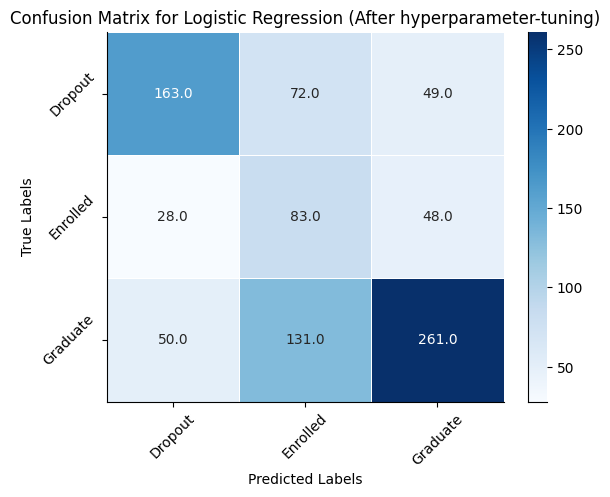

In [12]:
classnames = ['Dropout','Enrolled','Graduate']
cm_logreg = confusion_matrix(Y_test,best_ypred_log,labels=[0,1,2])

log_heatmap = sns.heatmap(cm_logreg,annot=True,fmt=".1f",linewidth=0.5,cmap='Blues',
            xticklabels = classnames, yticklabels = classnames)

log_heatmap.set(xlabel='Predicted Labels', ylabel='True Labels')
log_heatmap.set_title('Confusion Matrix for Logistic Regression (After hyperparameter-tuning)')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
sns.despine()

My Logistic Regression Model's Baseline vs Tuned Performance Comparison

In [13]:
best_weighted_F1_log = f1_score(Y_test,best_ypred_log,average='weighted')
best_bal_acc_log = balanced_accuracy_score(Y_test,best_ypred_log)
best_class_report_log = classification_report(Y_test,best_ypred_log)
best_conf_matrix_log = confusion_matrix(Y_test,best_ypred_log)

log_reg_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'Baseline': [
        accuracy_score(Y_test,logY_pred),
        bal_acc_log,
        macro_F1_log,
        weighted_F1_log
    ],
    'Tuned_Model': [
        accuracy_score(Y_test,best_ypred_log),
        best_bal_acc_log,
        log_best.best_score_,
        best_weighted_F1_log
    ]
})

log_reg_comparison['Change'] = log_reg_comparison['Tuned_Model'] - log_reg_comparison['Baseline']
print(log_reg_comparison.set_index('Metric').round(4).to_string())

                   Baseline  Tuned_Model  Change
Metric                                          
Accuracy             0.5763       0.5729 -0.0034
Balanced Accuracy    0.5635       0.5622 -0.0013
Macro F1             0.5513       0.5729  0.0217
Weighted F1          0.5950       0.5922 -0.0028


Cross-Model Performance Comparison for both Tuned Models

In [14]:
cross_tuned_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'Logistic Regression': [
      accuracy_score(Y_test,best_ypred_log),
      balanced_accuracy_score(Y_test,best_ypred_log),
      f1_score(Y_test,best_ypred_log,average='macro'),
      f1_score(Y_test,best_ypred_log,average='weighted')
    ],
    'LDA': [
        accuracy_score(Y_test,best_ypred_lda),
        balanced_accuracy_score(Y_test,best_ypred_lda),
        f1_score(Y_test,best_ypred_lda,average='macro'),
        f1_score(Y_test,best_ypred_lda,average='weighted')
    ]
})

cross_tuned_comparison['Better Model'] = [
    'LR' if cross_tuned_comparison['Logistic Regression'][i]>cross_tuned_comparison['LDA'][i] else
    'LDA' for i in range(len(cross_tuned_comparison['Logistic Regression']))
]

print(cross_tuned_comparison.set_index('Metric').round(4).to_string())

                   Logistic Regression     LDA Better Model
Metric                                                     
Accuracy                        0.5729  0.6328          LDA
Balanced Accuracy               0.5622  0.5334           LR
Macro F1                        0.5488  0.5386           LR
Weighted F1                     0.5922  0.6151          LDA


Plot ROC curve using the Tuned models

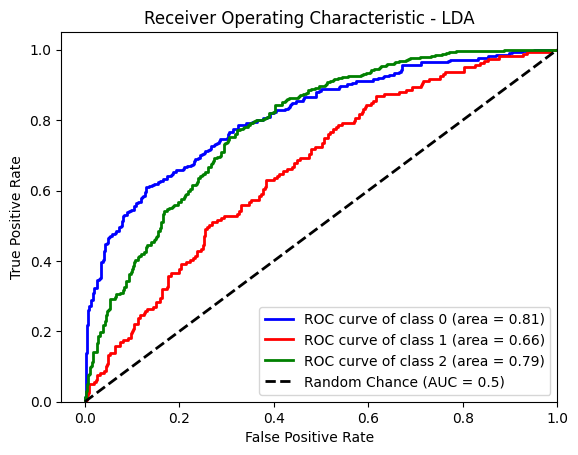

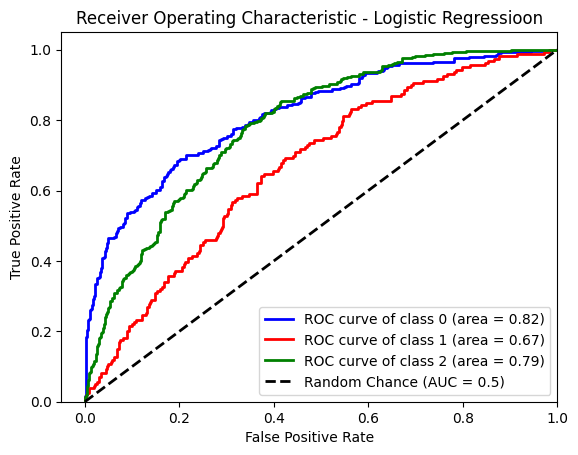

In [15]:
# Code snippet found from stack exchange - https://stackoverflow.com/questions/45332410/roc-for-multiclass-classification

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_roc_curve(X_test_scaled,Y_test,best_classifier,model_name):

  y_labels = [0,1,2]
  ylabel_binarized = label_binarize(Y_test,classes=y_labels)
  num_classes = ylabel_binarized.shape[1]

  tpr = dict()
  fpr = dict()
  roc_auc = dict()

  # Using the best estimators after fine-tuning my classifiers
  y_best = best_classifier.predict_proba(X_test_scaled)

  for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(ylabel_binarized[:,i],y_best[:,i])
    roc_auc[i] = auc(fpr[i],tpr[i])

  colors = cycle(['blue','red','green'])
  for j,color in zip(range(num_classes),colors):
    plt.plot(fpr[j],tpr[j],color=color,linewidth = 2,label='ROC curve of class {0} (area = {1:0.2f})'.format(j, roc_auc[j]))

  plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2, color='black', label='Random Chance (AUC = 0.5)')
  plt.xlim([-0.05, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f"Receiver Operating Characteristic - {model_name}")
  plt.legend(loc="lower right")
  plt.show()

plot_roc_curve(X_test_scaled,Y_test,best_estimator_lda,'LDA')
plot_roc_curve(X_test_scaled,Y_test,best_estimator_logreg,'Logistic Regressioon')

In [16]:
# Overall macro AUC for both classifiers
from sklearn.metrics import roc_auc_score

y_labels = [0,1,2]
ylabel_binarized = label_binarize(Y_test,classes=y_labels)
num_classes = ylabel_binarized.shape[1]

lda_auc = roc_auc_score(ylabel_binarized, best_estimator_lda.predict_proba(X_test_scaled), multi_class='ovr', average='macro')
logreg_auc = roc_auc_score(ylabel_binarized, best_estimator_logreg.predict_proba(X_test_scaled), multi_class='ovr', average='macro')

print(f'LDA Macro ROC-AUC:  {lda_auc:.4f}')
print(f'Logistic Regression Macro ROC-AUC:   {logreg_auc:.4f}')

LDA Macro ROC-AUC:  0.7555
Logistic Regression Macro ROC-AUC:   0.7573


Saving my evaluation results in a separate file for comparison with my teammates' analyses

In [17]:
import os

PROJECT_DIR = '/content/drive/MyDrive/COMM074_Project'

RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

my_results = pd.DataFrame([
    {
        'member': 'Pavan',
        'model': 'LDA (Linear Discriminant Analysis)',
        'model_type': 'unique',
        'best_params': str(lda_grid.best_params_),
        'accuracy': accuracy_score(Y_test, best_ypred_lda),
        'balanced_accuracy': balanced_accuracy_score(Y_test,best_ypred_lda),
        'macro_f1': f1_score(Y_test,best_ypred_lda, average='macro'),
        'weighted_f1': f1_score(Y_test,best_ypred_lda,average='weighted'),
        'roc_auc': lda_auc,
        'dropout_f1': f1_score(Y_test, best_ypred_lda, average=None)[0],
        'enrolled_f1': f1_score(Y_test, best_ypred_lda, average=None)[1],
        'graduate_f1': f1_score(Y_test, best_ypred_lda, average=None)[2],
    },
    {
        'member': 'Pavan',
        'model': 'Logistic Regression',
        'model_type': 'shared',
        'best_params': str(log_grid.best_params_),
        'accuracy': accuracy_score(Y_test, best_ypred_log),
        'balanced_accuracy': balanced_accuracy_score(Y_test,best_ypred_log),
        'macro_f1': f1_score(Y_test,best_ypred_log, average='macro'),
        'weighted_f1': f1_score(Y_test,best_ypred_log, average='weighted'),
        'roc_auc': logreg_auc,
        'dropout_f1': f1_score(Y_test,best_ypred_log, average=None)[0],
        'enrolled_f1': f1_score(Y_test,best_ypred_log, average=None)[1],
        'graduate_f1': f1_score(Y_test,best_ypred_log, average=None)[2],
    },
])

results_path = os.path.join(RESULTS_DIR, 'results_pavan.csv')
my_results.to_csv(results_path, index=False)

print(f'Saved to: {results_path}')
print(my_results[['member', 'model', 'balanced_accuracy', 'macro_f1', 'roc_auc']].to_string(index=False))

Saved to: /content/drive/MyDrive/COMM074_Project/results/results_pavan.csv
member                              model  balanced_accuracy  macro_f1  roc_auc
 Pavan LDA (Linear Discriminant Analysis)           0.533412  0.538617 0.755493
 Pavan                Logistic Regression           0.562151  0.548829 0.757314
